In [4]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor
import warnings


In [ ]:
#MARKET MAKER 1-9 LOOSE - IGNORE THIS IS JUST CURSORY

def run_adaptive_market_maker(data_folder="hackathon_data", num_rounds=9):
    results = []

    for round_num in range(1, num_rounds + 1):
        print(f"\n--- Processing Round {round_num} ---")
        
        train_path = os.path.join(data_folder, f"stock_{round_num}_train.csv")
        test_path = os.path.join(data_folder, f"stock_{round_num}_test.csv")
        
        try:
            train = pd.read_csv(train_path)
            test = pd.read_csv(test_path)
        except FileNotFoundError:
            print(f"Data for round {round_num} not found.")
            continue

        X = train.drop("target", axis=1)
        y = train["target"]
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        test_scaled = scaler.transform(test)

        X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

        #AMODEL SELECTION
        num_rows = train.shape[0]
        print(f"Dataset size: {num_rows} rows. ", end="")
        
        if num_rows < 500:
            print("Using Ridge Regression (Small Data Strategy)")
            # Alpha acts as a dampener to prevent overfitting on small data
            model = Ridge(alpha=1.0, random_state=42) 
        else:
            print("Using XGBoost (Large Data Strategy)")
            model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

        # Train and validate to find our error margin
        model.fit(X_train, y_train)
        val_preds = model.predict(X_val)
        model_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        print(f"Validation RMSE: {model_rmse:.4f}")

        # Retrain on ALL data for the final prediction
        model.fit(X_scaled, y)
        mid_pred = model.predict(test_scaled)[0]

        spread_multiplier = 1.0 
        
        bid_pred = mid_pred - (spread_multiplier * model_rmse)
        ask_pred = mid_pred + (spread_multiplier * model_rmse)
        spread = ask_pred - bid_pred

        print(f"Predicted Target (Mid): {mid_pred:.2f}")
        print(f"Bid Price: {bid_pred:.2f}")
        print(f"Ask Price: {ask_pred:.2f}")
        print(f"Spread: {spread:.2f}")

        results.append({
            'Round': round_num,
            'Mid': mid_pred,
            'Bid': bid_pred,
            'Ask': ask_pred,
            'Spread': spread
        })

    return pd.DataFrame(results)

run_adaptive_market_maker()


--- Processing Round 1 ---
Dataset size: 19999 rows. Using XGBoost (Large Data Strategy)
Validation RMSE: 5.4547
Predicted Target (Mid): 275.96
Bid Price: 270.50
Ask Price: 281.41
Spread: 10.91

--- Processing Round 2 ---
Dataset size: 1499 rows. Using XGBoost (Large Data Strategy)
Validation RMSE: 17.4326
Predicted Target (Mid): 228.17
Bid Price: 210.74
Ask Price: 245.60
Spread: 34.87

--- Processing Round 3 ---
Dataset size: 29 rows. Using Ridge Regression (Small Data Strategy)
Validation RMSE: 25.5710
Predicted Target (Mid): 257.82
Bid Price: 232.25
Ask Price: 283.39
Spread: 51.14

--- Processing Round 4 ---
Dataset size: 9999 rows. Using XGBoost (Large Data Strategy)
Validation RMSE: 24.6505
Predicted Target (Mid): 236.83
Bid Price: 212.18
Ask Price: 261.48
Spread: 49.30

--- Processing Round 5 ---
Dataset size: 799 rows. Using XGBoost (Large Data Strategy)
Validation RMSE: 25.3603
Predicted Target (Mid): 250.30
Bid Price: 224.94
Ask Price: 275.66
Spread: 50.72

--- Processing Rou

,Round,Mid,Bid,Ask,Spread
0,1,275.958313,270.503640,281.412986,10.909346
1,2,228.171112,210.738535,245.603689,34.865154
2,3,257.823684,232.252684,283.394684,51.142000
3,4,236.829468,212.178944,261.479991,49.301047
4,5,250.299652,224.939396,275.659908,50.720511
5,6,174.920233,104.161389,245.679078,141.517689
6,7,213.574905,197.436571,229.713239,32.276668
7,8,201.026703,174.693052,227.360354,52.667302
8,9,219.999141,175.002792,264.995491,89.992699


=== QMML Hackathon: Exploratory Data Analysis ===

--- STOCK 1 EDA REPORT ---
Dataset Size: 19999 rows, 5 features.
✅ Target distribution is relatively normal.
✅ Feature scales are clean and contained (No extreme outliers detected).

--- STOCK 2 EDA REPORT ---
Dataset Size: 1499 rows, 15 features.
✅ Target distribution is relatively normal.
✅ Feature scales are clean and contained (No extreme outliers detected).

--- STOCK 3 EDA REPORT ---
Dataset Size: 29 rows, 4 features.
✅ Target distribution is relatively normal.
✅ Feature scales are clean and contained (No extreme outliers detected).

--- STOCK 4 EDA REPORT ---
Dataset Size: 9999 rows, 12 features.
✅ Target distribution is relatively normal.
✅ Feature scales are clean and contained (No extreme outliers detected).

--- STOCK 5 EDA REPORT ---
Dataset Size: 799 rows, 20 features.
✅ Target distribution is relatively normal.
✅ Feature scales are clean and contained (No extreme outliers detected).

--- STOCK 6 EDA REPORT ---
Dataset Siz

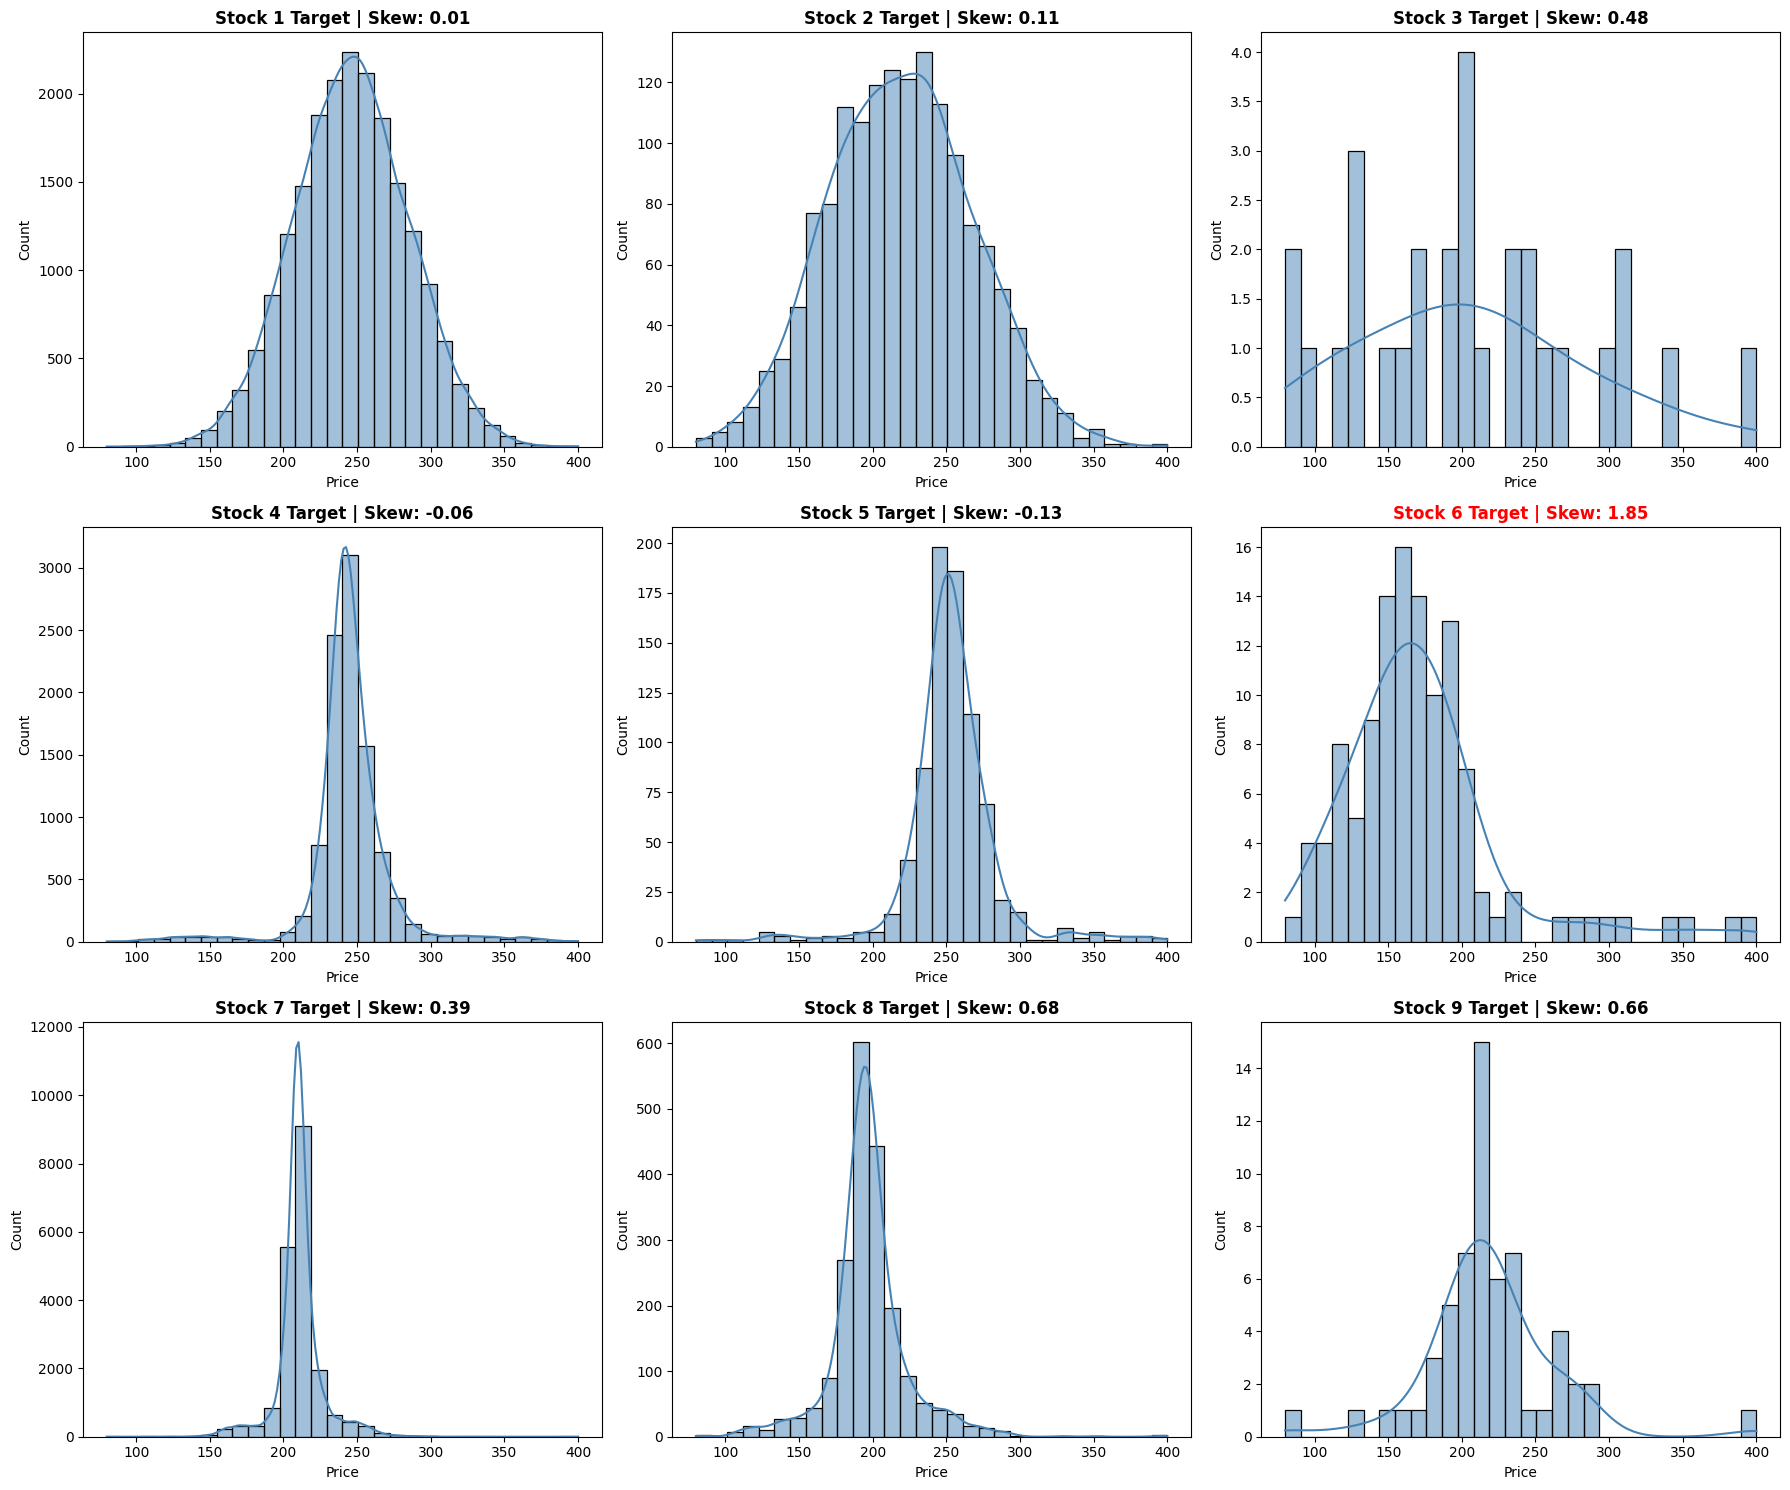

In [ ]:
#EXPLORATORY ANALYSIS

def run_hackathon_eda(data_folder="hackathon_data", num_stocks=9):
    print("=== QMML Hackathon: Exploratory Data Analysis ===")
    
    # 1. Setup the 3x3 Grid for Target Histograms
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    # 2. Loop through all 9 stocks
    for i in range(1, num_stocks + 1):
        file_path = os.path.join(data_folder, f"stock_{i}_train.csv")
        
        # Check if the file exists before crashing
        if not os.path.exists(file_path):
            axes[i-1].set_title(f"Stock {i} (File Not Found)", color='red')
            continue
            
        df = pd.read_csv(file_path)
        
        # --- PART A: TARGET DISTRIBUTION (THE SKEW TRAP) ---
        target = df['target']
        skewness = target.skew()
        
        # Plot the histogram
        sns.histplot(target, kde=True, ax=axes[i-1], color='steelblue', bins=30)
        
        # If skewness > 1.0 or < -1.0, it's highly skewed and dangerous
        title_color = 'red' if abs(skewness) > 1.0 else 'black'
        axes[i-1].set_title(f"Stock {i} Target | Skew: {skewness:.2f}", color=title_color, fontweight='bold')
        axes[i-1].set_xlabel("Price")
        
        # --- PART B: FEATURE OUTLIERS (THE SCALING TRAP) ---
        features = df.drop('target', axis=1)
        
        # Calculate summary statistics for the features
        feature_summary = pd.DataFrame({
            'Min': features.min(),
            'Max': features.max(),
            'Mean': features.mean(),
            'Range': features.max() - features.min()
        })
        
        print(f"\n--- STOCK {i} EDA REPORT ---")
        print(f"Dataset Size: {len(df)} rows, {features.shape[1]} features.")
        
        if abs(skewness) > 1.0:
            print("⚠️ WARNING: Target is highly skewed! Consider using Log Transformation (np.log1p) before training.")
        else:
            print("✅ Target distribution is relatively normal.")
            
        # Check for extreme feature ranges (Assuming standard ranges should be under 50 based on Stock 1/2)
        outlier_columns = feature_summary[feature_summary['Range'] > 50]
        
        if not outlier_columns.empty:
            print("⚠️ WARNING: Extreme feature outliers detected. Standard scaling will fail!")
            print("Use RobustScaler instead of StandardScaler for these columns:")
            print(outlier_columns[['Min', 'Max', 'Range']].to_string())
        else:
            print("✅ Feature scales are clean and contained (No extreme outliers detected).")

    # 3. Finalize and show the plots
    plt.tight_layout()
    plt.savefig("all_9_stocks_histograms.png", dpi=300)
    print("\n[!] Histogram grid saved as 'all_9_stocks_histograms.png'. Open it to visually inspect the distributions.")
    # plt.show() # Uncomment if running in a Jupyter Notebook

# Make sure your files are in the 'hackathon_data' folder, then run:
run_hackathon_eda(data_folder="hackathon_data", num_stocks=9)

In [12]:
#HYPERPARAMETER TUNING

# Suppress warnings for cleaner output during the hyperparameter search
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

def run_ultimate_tuning_lab(stock_num, data_folder="hackathon_data", n_trials=100):
    print(f"========== THE QUANT LAB: STOCK {stock_num} ==========")
    
    # 1. Load Data
    # Adjust the path if your CSVs are stored somewhere else
    train = pd.read_csv(f"{data_folder}/stock_{stock_num}_train.csv")
    X = train.drop("target", axis=1)
    y = train["target"]
    num_rows = len(train)
    
    # --- UPGRADE 1: Target Log-Normal Check ---
    skewness = y.skew()
    apply_log_transform = abs(skewness) > 1.0
    if apply_log_transform:
        print(f"[!] Extreme Target Skew ({skewness:.2f}) Detected. Applying Log(x+1) Transformation.")
    else:
        print(f"[+] Target Skew ({skewness:.2f}) is stable. No transformation needed.")

    # --- UPGRADE 2: Chronological Time Series Split ---
    tscv = TimeSeriesSplit(n_splits=5)

    # Bayesian Optimization (Optuna Objective Function) ---
    def objective(trial):
        scaler_type = trial.suggest_categorical("scaler", ["Standard", "Robust"])
        scaler = StandardScaler() if scaler_type == "Standard" else RobustScaler()
        
        # SMALL DATASETS (< 500 rows): Linear Models
        if num_rows < 500:
            model_type = trial.suggest_categorical("model", ["Lasso", "Ridge"])
            alpha = trial.suggest_float("alpha", 0.001, 100.0, log=True)
            if model_type == "Lasso":
                base_model = Lasso(alpha=alpha, random_state=42, max_iter=2000)
            else:
                base_model = Ridge(alpha=alpha, random_state=42)
                
        # LARGE DATASETS (>= 500 rows): Heavyweight Tree Fight
        else:
            model_type = trial.suggest_categorical("model", ["HistGBM", "XGBoost", "LightGBM"])
            
            if model_type == "HistGBM":
                base_model = HistGradientBoostingRegressor(
                    max_iter=trial.suggest_int("max_iter", 100, 500),
                    learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                    max_depth=trial.suggest_int("max_depth", 3, 9),
                    random_state=42
                )
            elif model_type == "XGBoost":
                import xgboost as xgb
                base_model = xgb.XGBRegressor(
                    n_estimators=trial.suggest_int("n_estimators", 100, 500),
                    learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                    max_depth=trial.suggest_int("max_depth", 3, 9),
                    subsample=trial.suggest_float("subsample", 0.5, 1.0),
                    random_state=42,
                    n_jobs=-1
                )
            elif model_type == "LightGBM":
                import lightgbm as lgb
                base_model = lgb.LGBMRegressor(
                    n_estimators=trial.suggest_int("n_estimators", 100, 500),
                    learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                    max_depth=trial.suggest_int("max_depth", 3, 9),
                    num_leaves=trial.suggest_int("num_leaves", 20, 100),
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1
                )
            
        # Wrap the model in the Log Transformer if skew was detected
        if apply_log_transform:
            model = TransformedTargetRegressor(
                regressor=base_model, func=np.log1p, inverse_func=np.expm1
            )
        else:
            model = base_model

        # Build the full pipeline
        pipeline = Pipeline([('scaler', scaler), ('model', model)])
        
        # Evaluate using Time Series Validation
        mae_scores = []
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            pipeline.fit(X_tr, y_tr)
            preds = pipeline.predict(X_val)
            mae_scores.append(mean_absolute_error(y_val, preds))
            
        return np.mean(mae_scores)

    # --- REPRODUCIBILITY LOCK ---
    sampler = optuna.samplers.TPESampler(seed=42)
    print(f"\n[Optuna] Commencing Bayesian Search over {n_trials} trials...")
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    
    best_params = study.best_params
    best_mae = study.best_value
    print(f"\n[+] Search Complete! Best Validation MAE: {best_mae:.4f}")
    print("Best Bayesian Parameters:")
    for key, value in best_params.items():
        print(f"    - {key}: {value}")

    # --- UPGRADE 4: The Feature Stability Report ---
    print("\n--- UPGRADE 5: FEATURE STABILITY REPORT ---")
    
    # Reconstruct the winning pipeline to extract feature importances
    scaler = StandardScaler() if best_params['scaler'] == "Standard" else RobustScaler()
    
    if num_rows < 500:
        if best_params['model'] == "Lasso":
            final_model = Lasso(alpha=best_params['alpha'], random_state=42)
        else:
            final_model = Ridge(alpha=best_params['alpha'], random_state=42)
    else:
        if best_params['model'] == "HistGBM":
            final_model = HistGradientBoostingRegressor(
                max_iter=best_params['max_iter'], 
                learning_rate=best_params['learning_rate'], 
                max_depth=best_params['max_depth'], 
                random_state=42
            )
        elif best_params['model'] == "XGBoost":
            import xgboost as xgb
            final_model = xgb.XGBRegressor(
                n_estimators=best_params['n_estimators'],
                learning_rate=best_params['learning_rate'],
                max_depth=best_params['max_depth'],
                subsample=best_params['subsample'],
                random_state=42,
                n_jobs=-1
            )
        elif best_params['model'] == "LightGBM":
            import lightgbm as lgb
            final_model = lgb.LGBMRegressor(
                n_estimators=best_params['n_estimators'],
                learning_rate=best_params['learning_rate'],
                max_depth=best_params['max_depth'],
                num_leaves=best_params['num_leaves'],
                random_state=42,
                n_jobs=-1,
                verbose=-1
            )
            
    if apply_log_transform:
        final_model_wrapped = TransformedTargetRegressor(
            regressor=final_model, func=np.log1p, inverse_func=np.expm1
        )
    else:
        final_model_wrapped = final_model
        
    pipeline = Pipeline([('scaler', scaler), ('model', final_model_wrapped)])
    
    # Extract importances across the 5 Time Series chunks
    importance_history = []
    
    for train_idx, val_idx in tscv.split(X):
        X_tr = X.iloc[train_idx]
        y_tr = y.iloc[train_idx]
        pipeline.fit(X_tr, y_tr)
        
        # Extract the core model (bypassing the log wrapper if it exists)
        trained_model = pipeline.named_steps['model']
        core_model = trained_model.regressor_ if apply_log_transform else trained_model
        
        # Extract weights (Linear) or importances (Trees)
        if hasattr(core_model, 'coef_'):
            importance_history.append(np.abs(core_model.coef_))
        elif hasattr(core_model, 'feature_importances_'):
            importance_history.append(core_model.feature_importances_)
        else:
            importance_history = None
            break
            
    if importance_history is not None:
        imp_df = pd.DataFrame(importance_history, columns=X.columns)
        imp_mean = imp_df.mean()
        imp_std = imp_df.std()
        
        # Handle zero-mean features to avoid division by zero
        stability_ratio = np.where(imp_mean > 0, imp_std / imp_mean, 999)
        stability_ratio = pd.Series(stability_ratio, index=X.columns)
        
        print("Feature Stability (Lower ratio = More Stable Signal):")
        for col in X.columns:
            if stability_ratio[col] == 999:
                print(f"  {col}: ❌ IGNORED (Zero Importance)")
            else:
                status = "❌ UNSTABLE (Noise)" if stability_ratio[col] > 1.0 else "✅ STABLE (Signal)"
                print(f"  {col}: {status} (Volatility: {stability_ratio[col]:.2f})")
    else:
        print("[!] Model does not easily expose feature importances. Skipped for speed.")

    print("\n======================================================\n")
    return best_params

# RUN
if __name__ == "__main__":
    # Ensure n_trials is at least 100
    best_hyperparameters = run_ultimate_tuning_lab(stock_num=3, data_folder="hackathon_data", n_trials=100)

========== THE QUANT LAB: STOCK 3 ==========
[+] Target Skew (0.48) is stable. No transformation needed.

[Optuna] Commencing Bayesian Search over 100 trials...

[+] Search Complete! Best Validation MAE: 23.7973
Best Bayesian Parameters:
    - scaler: Robust
    - model: Lasso
    - alpha: 0.0010026444968410334

--- UPGRADE 5: FEATURE STABILITY REPORT ---
Feature Stability (Lower ratio = More Stable Signal):
  col_0: ✅ STABLE (Signal) (Volatility: 0.10)
  col_1: ✅ STABLE (Signal) (Volatility: 0.42)
  col_2: ✅ STABLE (Signal) (Volatility: 0.52)
  col_3: ✅ STABLE (Signal) (Volatility: 0.83)




In [15]:
#STOCK 1

# ==========================================
# A. LOAD DATA (Change stock_num for each round)
# ==========================================
stock_num = 1
train = pd.read_csv(f"hackathon_data/stock_{stock_num}_train.csv")
test = pd.read_csv(f"hackathon_data/stock_{stock_num}_test.csv")

X = train.drop("target", axis=1)
y = train["target"]

# ==========================================
# B. THE MODULAR PIPELINE (Optuna Tuned)
# ==========================================

# 1. Update the Scaler
scaler = RobustScaler()

# 2. Update the Model
tree_model = xgb.XGBRegressor(
    n_estimators=492,
    learning_rate=0.020053478210758077,
    max_depth=4,
    subsample=0.5480678723641842,
    random_state=42,
    n_jobs=-1
)

# 3. Combine them into your final pipeline
model = Pipeline([
    ('scaler', scaler),
    ('model', tree_model)
])

# ==========================================
# C. RISK ANALYSIS (5-Fold Cross Validation)
# ==========================================
print(f"--- Running Risk Diagnostics for Stock {stock_num} ---")
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

mean_mae = (-cv_results['test_mae']).mean()
mean_rmse = (-cv_results['test_rmse']).mean()
cv_volatility = (-cv_results['test_mae']).std() / mean_mae

outlier_ratio = mean_rmse / mean_mae
num_rows = len(train)

print(f"Dataset Size:  {num_rows} rows")
print(f"Average MAE:   {mean_mae:.4f}")
print(f"Average RMSE:  {mean_rmse:.4f}")
print(f"Outlier Ratio: {outlier_ratio:.4f}")
print(f"CV Volatility: {cv_volatility:.2%}")

# ==========================================
# D. THE DECISION ENGINE (Automatic Spread Sizing)
# ==========================================
# ==========================================
# D. THE DYNAMIC DECISION ENGINE
# ==========================================
print("\n--- Strategy Engine ---")

# YOUR STRATEGY DIAL (1 = Safest, 10 = Most Aggressive)
# Set this based on how badly you want to win the Market Maker spot for this round.
target_aggression = 8

# 1. The Hard Circuit Breakers (Absolute Defense)
if num_rows < 500:
    print("Trigger: Small Dataset. CIRCUIT BREAKER ACTIVATED.")
    spread_margin = mean_rmse * 1.0  
    
elif outlier_ratio > 1.30 or cv_volatility > 0.15:
    print("Trigger: High Tail Risk. CIRCUIT BREAKER ACTIVATED.")
    spread_margin = mean_rmse * 1.0  

# 2. Continuous Risk Scaling (Fluid Aggression)
else:
    print("Trigger: Model Stable. Calculating dynamic confidence spread...")
    
    # Scale aggression from 1-10 into a base math multiplier (10 -> 0.1, 1 -> 1.0)
    base_multiplier = (11 - target_aggression) / 10.0
    
    # We penalize the multiplier based on how volatile the cross-validation was.
    # If volatility is 1% (0.01), it barely changes the multiplier.
    # If volatility is 10% (0.10), it significantly widens the spread.
    volatility_penalty = cv_volatility * 5.0 
    
    # Calculate final dynamic multiplier (Capped at a minimum of 0.05 so spread is never exactly zero)
    dynamic_multiplier = max(0.05, base_multiplier + volatility_penalty)
    
    # Apply the dynamic multiplier to the MAE
    spread_margin = mean_mae * dynamic_multiplier
    
    print(f"  -> User Aggression Level: {target_aggression}/10")
    print(f"  -> Model Volatility Penalty: +{volatility_penalty:.3f}")
    print(f"  -> Final Applied MAE Multiplier: {dynamic_multiplier:.3f}")

# ==========================================
# E. FINAL PREDICTION & SUBMISSION NUMBERS
# ==========================================
# Retrain the pipeline on ALL available training data for maximum accuracy
model.fit(X, y)

# Predict the single missing target value in the test set
mid_pred = model.predict(test)[0]

# Calculate the final Bid (Buy) and Ask (Sell) prices
bid_pred = mid_pred - spread_margin
ask_pred = mid_pred + spread_margin
total_spread = ask_pred - bid_pred

print(f"\n=====================================")
print(f"🏆 FINAL SUBMISSION: STOCK {stock_num} 🏆")
print(f"=====================================")
print(f"Predicted Mid: {mid_pred:.4f}")
print(f"Bid Price:     {bid_pred:.4f}")
print(f"Ask Price:     {ask_pred:.4f}")
print(f"Total Spread:  {total_spread:.4f}")
print(f"=====================================")

--- Running Risk Diagnostics for Stock 1 ---
Dataset Size:  19999 rows
Average MAE:   4.1244
Average RMSE:  5.2231
Outlier Ratio: 1.2664
CV Volatility: 0.63%

--- Strategy Engine ---
Trigger: Model Stable. Calculating dynamic confidence spread...
  -> User Aggression Level: 8/10
  -> Model Volatility Penalty: +0.031
  -> Final Applied MAE Multiplier: 0.331

🏆 FINAL SUBMISSION: STOCK 1 🏆
Predicted Mid: 274.5934
Bid Price:     273.2264
Ask Price:     275.9605
Total Spread:  2.7341


In [16]:
#STOCK 2

# ==========================================
# A. LOAD DATA (Change stock_num for each round)
# ==========================================
stock_num = 2
train = pd.read_csv(f"hackathon_data/stock_{stock_num}_train.csv")
test = pd.read_csv(f"hackathon_data/stock_{stock_num}_test.csv")

X = train.drop("target", axis=1)
y = train["target"]

# ==========================================
# B. THE MODULAR PIPELINE (Swap this based on Optuna results)
# ==========================================


# 1. Update the Scaler
scaler = RobustScaler()

# 2. Update the Model
tree_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.045663081372688076,
    max_depth=3,
    subsample=0.5284498661704208,
    random_state=42,
    n_jobs=-1
)

# 3. Combine them into your final pipeline
model = Pipeline([
    ('scaler', scaler),
    ('model', tree_model)
])


# ==========================================
# C. RISK ANALYSIS (5-Fold Cross Validation)
# ==========================================
print(f"--- Running Risk Diagnostics for Stock {stock_num} ---")
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

mean_mae = (-cv_results['test_mae']).mean()
mean_rmse = (-cv_results['test_rmse']).mean()
cv_volatility = (-cv_results['test_mae']).std() / mean_mae

outlier_ratio = mean_rmse / mean_mae
num_rows = len(train)

print(f"Dataset Size:  {num_rows} rows")
print(f"Average MAE:   {mean_mae:.4f}")
print(f"Average RMSE:  {mean_rmse:.4f}")
print(f"Outlier Ratio: {outlier_ratio:.4f}")
print(f"CV Volatility: {cv_volatility:.2%}")

# ==========================================
# D. THE DYNAMIC DECISION ENGINE
# ==========================================
print("\n--- Strategy Engine ---")

# YOUR STRATEGY DIAL (1 = Safest, 10 = Most Aggressive)
# Set this based on how badly you want to win the Market Maker spot for this round.
target_aggression = 5  

# 1. The Hard Circuit Breakers (Absolute Defense)
if num_rows < 500:
    print("Trigger: Small Dataset. CIRCUIT BREAKER ACTIVATED.")
    spread_margin = mean_rmse * 1.0  
    
elif outlier_ratio > 1.30 or cv_volatility > 0.15:
    print("Trigger: High Tail Risk. CIRCUIT BREAKER ACTIVATED.")
    spread_margin = mean_rmse * 1.0  

# 2. Continuous Risk Scaling (Fluid Aggression)
else:
    print("Trigger: Model Stable. Calculating dynamic confidence spread...")
    
    # Scale aggression from 1-10 into a base math multiplier (10 -> 0.1, 1 -> 1.0)
    base_multiplier = (11 - target_aggression) / 10.0
    
    # We penalize the multiplier based on how volatile the cross-validation was.
    # If volatility is 1% (0.01), it barely changes the multiplier.
    # If volatility is 10% (0.10), it significantly widens the spread.
    volatility_penalty = cv_volatility * 5.0 
    
    # Calculate final dynamic multiplier (Capped at a minimum of 0.05 so spread is never exactly zero)
    dynamic_multiplier = max(0.05, base_multiplier + volatility_penalty)
    
    # Apply the dynamic multiplier to the MAE
    spread_margin = mean_mae * dynamic_multiplier
    
    print(f"  -> User Aggression Level: {target_aggression}/10")
    print(f"  -> Model Volatility Penalty: +{volatility_penalty:.3f}")
    print(f"  -> Final Applied MAE Multiplier: {dynamic_multiplier:.3f}")

# ==========================================
# E. FINAL PREDICTION & SUBMISSION NUMBERS
# ==========================================
# Retrain the pipeline on ALL available training data for maximum accuracy
model.fit(X, y)

# Predict the single missing target value in the test set
mid_pred = model.predict(test)[0]

# Calculate the final Bid (Buy) and Ask (Sell) prices
bid_pred = mid_pred - spread_margin
ask_pred = mid_pred + spread_margin
total_spread = ask_pred - bid_pred

print(f"\n=====================================")
print(f"🏆 FINAL SUBMISSION: STOCK {stock_num} 🏆")
print(f"=====================================")
print(f"Predicted Mid: {mid_pred:.4f}")
print(f"Bid Price:     {bid_pred:.4f}")
print(f"Ask Price:     {ask_pred:.4f}")
print(f"Total Spread:  {total_spread:.4f}")
print(f"=====================================")

--- Running Risk Diagnostics for Stock 2 ---
Dataset Size:  1499 rows
Average MAE:   10.7900
Average RMSE:  13.6294
Outlier Ratio: 1.2632
CV Volatility: 4.81%

--- Strategy Engine ---
Trigger: Model Stable. Calculating dynamic confidence spread...
  -> User Aggression Level: 5/10
  -> Model Volatility Penalty: +0.241
  -> Final Applied MAE Multiplier: 0.841

🏆 FINAL SUBMISSION: STOCK 2 🏆
Predicted Mid: 223.4930
Bid Price:     214.4230
Ask Price:     232.5630
Total Spread:  18.1399


In [17]:
#STOCK 3

# ==========================================
# A. LOAD DATA (Change stock_num for each round)
# ==========================================
stock_num = 3
train = pd.read_csv(f"hackathon_data/stock_{stock_num}_train.csv")
test = pd.read_csv(f"hackathon_data/stock_{stock_num}_test.csv")

X = train.drop("target", axis=1)
y = train["target"]

# ==========================================
# B. THE MODULAR PIPELINE (Swap this based on Optuna results)
# ==========================================

# 1. Update the Scaler
# Optuna chose the RobustScaler to handle underlying outliers.
scaler = RobustScaler()

# 2. Update the Base Model
# Optuna selected Lasso with a very low penalty.
# We hardcode random_state=42 and max_iter=2000 for stability.
linear_model = Lasso(
    alpha=0.0010026444968410334, 
    random_state=42, 
    max_iter=2000
)

# 3. Combine them into your final pipeline
# No TransformedTargetRegressor is needed because the skew was low!
model = Pipeline([
    ('scaler', scaler),
    ('model', linear_model)
])

# ==========================================
# C. RISK ANALYSIS (5-Fold Cross Validation)
# ==========================================
print(f"--- Running Risk Diagnostics for Stock {stock_num} ---")
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

mean_mae = (-cv_results['test_mae']).mean()
mean_rmse = (-cv_results['test_rmse']).mean()
cv_volatility = (-cv_results['test_mae']).std() / mean_mae

outlier_ratio = mean_rmse / mean_mae
num_rows = len(train)

print(f"Dataset Size:  {num_rows} rows")
print(f"Average MAE:   {mean_mae:.4f}")
print(f"Average RMSE:  {mean_rmse:.4f}")
print(f"Outlier Ratio: {outlier_ratio:.4f}")
print(f"CV Volatility: {cv_volatility:.2%}")

# ==========================================
# D. THE DYNAMIC DECISION ENGINE
# ==========================================
print("\n--- Strategy Engine ---")

# YOUR STRATEGY DIAL (1 = Safest, 10 = Most Aggressive)
# Set this based on how badly you want to win the Market Maker spot for this round.
target_aggression = 5  

# 1. The Hard Circuit Breakers (Absolute Defense)
if num_rows < 500:
    print("Trigger: Small Dataset. CIRCUIT BREAKER ACTIVATED.")
    spread_margin = mean_rmse * 1.0  
    
elif outlier_ratio > 1.30 or cv_volatility > 0.15:
    print("Trigger: High Tail Risk. CIRCUIT BREAKER ACTIVATED.")
    spread_margin = mean_rmse * 1.0  

# 2. Continuous Risk Scaling (Fluid Aggression)
else:
    print("Trigger: Model Stable. Calculating dynamic confidence spread...")
    
    # Scale aggression from 1-10 into a base math multiplier (10 -> 0.1, 1 -> 1.0)
    base_multiplier = (11 - target_aggression) / 10.0
    
    # We penalize the multiplier based on how volatile the cross-validation was.
    # If volatility is 1% (0.01), it barely changes the multiplier.
    # If volatility is 10% (0.10), it significantly widens the spread.
    volatility_penalty = cv_volatility * 5.0 
    
    # Calculate final dynamic multiplier (Capped at a minimum of 0.05 so spread is never exactly zero)
    dynamic_multiplier = max(0.05, base_multiplier + volatility_penalty)
    
    # Apply the dynamic multiplier to the MAE
    spread_margin = mean_mae * dynamic_multiplier
    
    print(f"  -> User Aggression Level: {target_aggression}/10")
    print(f"  -> Model Volatility Penalty: +{volatility_penalty:.3f}")
    print(f"  -> Final Applied MAE Multiplier: {dynamic_multiplier:.3f}")

# ==========================================
# E. FINAL PREDICTION & SUBMISSION NUMBERS
# ==========================================
# Retrain the pipeline on ALL available training data for maximum accuracy
model.fit(X, y)

# Predict the single missing target value in the test set
mid_pred = model.predict(test)[0]

# Calculate the final Bid (Buy) and Ask (Sell) prices
bid_pred = mid_pred - spread_margin
ask_pred = mid_pred + spread_margin
total_spread = ask_pred - bid_pred

print(f"\n=====================================")
print(f"🏆 FINAL SUBMISSION: STOCK {stock_num} 🏆")
print(f"=====================================")
print(f"Predicted Mid: {mid_pred:.4f}")
print(f"Bid Price:     {bid_pred:.4f}")
print(f"Ask Price:     {ask_pred:.4f}")
print(f"Total Spread:  {total_spread:.4f}")
print(f"=====================================")

--- Running Risk Diagnostics for Stock 3 ---
Dataset Size:  29 rows
Average MAE:   19.3445
Average RMSE:  24.4710
Outlier Ratio: 1.2650
CV Volatility: 13.48%

--- Strategy Engine ---
Trigger: Small Dataset. CIRCUIT BREAKER ACTIVATED.

🏆 FINAL SUBMISSION: STOCK 3 🏆
Predicted Mid: 259.5604
Bid Price:     235.0894
Ask Price:     284.0314
Total Spread:  48.9419
